In [1]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — VANTAGE MT5 DATA LOADER  (v9pro companion)
#
# Prerequisites (Windows only — MT5 Python API is Windows-only):
#   pip install MetaTrader5 pandas pytz
#
# What this cell does:
#   1. Connects to your locally-running Vantage MT5 terminal
#   2. Pulls OHLCV bars for the symbol + timeframe you set
#   3. Renames columns to match what run_backtest() expects:
#      time | open | high | low | close | tick_volume
#   4. Optionally caches to Parquet so you don't re-download every run
#   5. Prints a health summary and shows the tail of the dataframe
# ══════════════════════════════════════════════════════════════════

import MetaTrader5 as mt5
import pandas as pd
import pytz
import datetime as _dt
import os

# ──────────────────────────────────────────────────────────────────
# ❶  CONNECTION — Vantage MT5 terminal
#     Leave login=None / password=None if your terminal is already
#     logged in; the API will reuse the active session.
# ──────────────────────────────────────────────────────────────────
MT5_LOGIN     = 24367452
MT5_PASSWORD  = "UY61&jYZ"          # e.g. "MyPass1!"
MT5_SERVER   = "VantageInternational-Demo"          # auto-detect from active session
#   Vantage live server  : "VantageInternational-Live"
#   Vantage demo server  : "VantageInternational-Demo"
#   Override example:
#   MT5_SERVER = "VantageInternational-Demo"

# Optional: path to terminal64.exe if MT5 is not in default location
MT5_PATH     = None          # e.g. r"C:\Program Files\Vantage MT5\terminal64.exe"

# ──────────────────────────────────────────────────────────────────
# ❷  WHAT TO FETCH
# ──────────────────────────────────────────────────────────────────
SYMBOL     = "XAUUSD"        # must match Market Watch spelling exactly
TIMEFRAME  = mt5.TIMEFRAME_M15   # e.g. TIMEFRAME_M1/M5/M15/H1/H4/D1

# Date range — set both for a fixed window, or leave DATE_END=None
# to pull right up to the latest available bar.
DATE_START = _dt.datetime(2023, 1, 1)    # inclusive
DATE_END   = None                        # None = now (UTC)

# ──────────────────────────────────────────────────────────────────
# ❸  CACHING  (recommended — avoids re-downloading on every run)
# ──────────────────────────────────────────────────────────────────
USE_CACHE    = True
CACHE_PATH   = f"{SYMBOL}_M15_vantage.parquet"   # saved next to this notebook
REFRESH_DAYS = 1    # if cache is older than this many days, re-fetch

# ──────────────────────────────────────────────────────────────────
# HELPERS
# ──────────────────────────────────────────────────────────────────
_TF_NAMES = {
    mt5.TIMEFRAME_M1:  "M1",  mt5.TIMEFRAME_M5:  "M5",
    mt5.TIMEFRAME_M15: "M15", mt5.TIMEFRAME_M30: "M30",
    mt5.TIMEFRAME_H1:  "H1",  mt5.TIMEFRAME_H4:  "H4",
    mt5.TIMEFRAME_D1:  "D1",  mt5.TIMEFRAME_W1:  "W1",
}

def _tf_name(tf):
    return _TF_NAMES.get(tf, str(tf))

def _cache_stale(path, max_age_days):
    if not os.path.exists(path):
        return True
    age = _dt.datetime.utcnow() - _dt.datetime.utcfromtimestamp(os.path.getmtime(path))
    return age.days >= max_age_days

def _connect():
    """Initialize MT5 terminal connection.  Returns True on success."""
    kwargs = {}
    if MT5_PATH:     kwargs["path"]     = MT5_PATH
    if MT5_LOGIN:    kwargs["login"]    = int(MT5_LOGIN)
    if MT5_PASSWORD: kwargs["password"] = MT5_PASSWORD
    if MT5_SERVER:   kwargs["server"]   = MT5_SERVER

    if not mt5.initialize(**kwargs):
        err = mt5.last_error()
        raise RuntimeError(
            f"MT5 initialize() failed: {err}\n"
            "  → Make sure Vantage MT5 terminal is open and logged in.\n"
            "  → On Mac/Linux: MT5 Python API requires Windows. "
            "Use a VM or Wine."
        )

    info = mt5.terminal_info()
    acct = mt5.account_info()
    print(f"✅  Connected to MT5")
    print(f"    Terminal : {info.name}  build {info.build}")
    print(f"    Broker   : {acct.company}")
    print(f"    Server   : {acct.server}")
    print(f"    Account  : {acct.login}  |  {acct.currency}  |  "
          f"Balance: {acct.balance:,.2f}")
    return True


def _fetch_bars(symbol, timeframe, date_start, date_end):
    """Pull bars from MT5 and return a clean DataFrame."""
    utc = pytz.utc
    t0  = utc.localize(date_start) if date_start.tzinfo is None else date_start
    t1  = (utc.localize(_dt.datetime.utcnow())
           if date_end is None
           else (utc.localize(date_end) if date_end.tzinfo is None else date_end))

    # Ensure symbol is visible in Market Watch
    if not mt5.symbol_select(symbol, True):
        raise ValueError(
            f"Symbol '{symbol}' not found or not selectable.\n"
            "  → Check the exact spelling in Market Watch (e.g. 'XAUUSD')."
        )

    bars = mt5.copy_rates_range(symbol, timeframe, t0, t1)
    if bars is None or len(bars) == 0:
        raise RuntimeError(
            f"No data returned for {symbol} {_tf_name(timeframe)} "
            f"{date_start.date()} → {t1.date()}\n"
            "  → Make sure sufficient history is loaded in the terminal.\n"
            "  → Right-click chart → History Center → download if needed."
        )

    df = pd.DataFrame(bars)
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df["time"] = df["time"].dt.tz_localize(None)   # naive UTC — matches engine expectations

    # Rename to engine-standard column names
    df = df.rename(columns={
        "open":        "open",
        "high":        "high",
        "low":         "low",
        "close":       "close",
        "tick_volume": "tick_volume",
        "real_volume": "real_volume",
        "spread":      "spread",
    })

    # Keep only what the engine uses (plus extras for diagnostics)
    keep = [c for c in ["time","open","high","low","close",
                        "tick_volume","real_volume","spread"] if c in df.columns]
    df = df[keep].reset_index(drop=True)
    return df


def _append_new_bars(df_cached, symbol, timeframe):
    """Fetch only bars newer than the last cached timestamp."""
    last = df_cached["time"].iloc[-1]
    t0   = last + _dt.timedelta(minutes=1)
    try:
        df_new = _fetch_bars(symbol, timeframe, t0, None)
    except RuntimeError:
        return df_cached   # nothing newer yet
    if df_new.empty:
        return df_cached
    combined = pd.concat([df_cached, df_new], ignore_index=True)
    combined = combined.drop_duplicates(subset="time").sort_values("time").reset_index(drop=True)
    return combined


# ──────────────────────────────────────────────────────────────────
# MAIN LOADER
# ──────────────────────────────────────────────────────────────────
def load_vantage_data(
    symbol    = None,
    timeframe = None,
    date_start= None,
    date_end  = None,
    use_cache = None,
    cache_path= None,
):
    """
    Connect to the local Vantage MT5 terminal, download OHLCV bars,
    and return a DataFrame ready for run_backtest().

    All parameters default to the module-level CONFIG values above.
    Pass explicit arguments to override for a single call.
    """
    sym  = symbol     or SYMBOL
    tf   = timeframe  or TIMEFRAME
    t0   = date_start or DATE_START
    t1   = date_end   or DATE_END
    uc   = use_cache  if use_cache  is not None else USE_CACHE
    cp   = cache_path or CACHE_PATH.replace("XAUUSD", sym).replace("M15", _tf_name(tf))

    connected = False
    df        = None

    # ── Try cache first ───────────────────────────────────────────
    if uc and os.path.exists(cp) and not _cache_stale(cp, REFRESH_DAYS):
        print(f"📂  Loading from cache: {cp}")
        df = pd.read_parquet(cp)
        df["time"] = pd.to_datetime(df["time"])

        # Append latest bars without full re-download
        _connect(); connected = True
        df = _append_new_bars(df, sym, tf)
        print(f"    Appended new bars → {len(df):,} total rows")

    else:
        # ── Full download ─────────────────────────────────────────
        if not connected:
            _connect(); connected = True
        print(f"\n📡  Fetching {sym} {_tf_name(tf)}  "
              f"{t0.date()} → {'now' if t1 is None else t1.date()}")
        df = _fetch_bars(sym, tf, t0, t1)

        if uc:
            df.to_parquet(cp, index=False)
            print(f"💾  Cached → {cp}")

    mt5.shutdown()

    # ── Health check ──────────────────────────────────────────────
    n_bars  = len(df)
    n_nulls = df[["open","high","low","close"]].isnull().sum().sum()
    n_dups  = df.duplicated(subset="time").sum()
    span    = f"{df['time'].iloc[0]}  →  {df['time'].iloc[-1]}"

    print(f"\n{'─'*56}")
    print(f"  Symbol     : {sym}")
    print(f"  Timeframe  : {_tf_name(tf)}")
    print(f"  Bars       : {n_bars:,}")
    print(f"  Span       : {span}")
    print(f"  Null OHLC  : {n_nulls}  {'⚠' if n_nulls else '✅'}")
    print(f"  Duplicates : {n_dups}   {'⚠' if n_dups  else '✅'}")
    print(f"{'─'*56}\n")

    if n_nulls:
        df = df.dropna(subset=["open","high","low","close"])
        print(f"  Dropped {n_nulls} rows with null OHLC values.")
    if n_dups:
        df = df.drop_duplicates(subset="time").sort_values("time").reset_index(drop=True)
        print(f"  Removed {n_dups} duplicate timestamps.")

    display(df.tail(10))
    return df


# ══════════════════════════════════════════════════════════════════
# RUN
# ══════════════════════════════════════════════════════════════════
# Uncomment to execute immediately when the cell runs:
# df = load_vantage_data()

print("✅  Vantage MT5 loader ready")
print("   Run:  df = load_vantage_data()")
print("   Then: trades, eq_df = run_backtest(df)")
print("         log_df = build_report(trades, eq_df)")
print()
print("   Common Vantage servers:")
print("     Live : VantageInternational-Live")
print("     Demo : VantageInternational-Demo")

✅  Vantage MT5 loader ready
   Run:  df = load_vantage_data()
   Then: trades, eq_df = run_backtest(df)
         log_df = build_report(trades, eq_df)

   Common Vantage servers:
     Live : VantageInternational-Live
     Demo : VantageInternational-Demo


In [6]:
# ══════════════════════════════════════════════════════════════════
# BACKTEST v9pro — CONFIG + LOGGING (drop-in companion to Cell 5)
#
# All parameters live here. Logging/export runs automatically
# after run_backtest(). Equity chart uses matplotlib.
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from IPython.display import display, HTML
import datetime as _dt
import warnings
warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────────────
# ❶  INSTRUMENT
# ──────────────────────────────────────────────────────────────────
SYMBOL            = "XAUUSD"        # display label
CONTRACT_SIZE     = 100             # $ per pip per lot

# ──────────────────────────────────────────────────────────────────
# ❷  CAPITAL
# ──────────────────────────────────────────────────────────────────
INITIAL_CAPITAL   = 10000.0        # starting balance in $

# ──────────────────────────────────────────────────────────────────
# ❸  POSITION SIZING
# ──────────────────────────────────────────────────────────────────
FIXED_LOT         = 0.05            # base lot size for entry + grids

# Grid lot multipliers: index 0 = first grid, 1 = second, etc.
# Each value is multiplied by FIXED_LOT.
# e.g. [1,1,1] → same size each grid | [1,2,4] → martingale
GRID_LOT_MULTIPLIERS = [2, 4, 4]    # up to 3 grid levels

# ──────────────────────────────────────────────────────────────────
# ❹  GRID SETTINGS
# ──────────────────────────────────────────────────────────────────
GRID_STEP         = 10.0             # price distance per grid level (pts)

# ──────────────────────────────────────────────────────────────────
# ❺  PROFIT TARGETS
# ──────────────────────────────────────────────────────────────────
SINGLE_TRADE_TP_PTS  = 10.0        # TP in pts when only 1 trade is open
TARGET_PROFIT_G1     = 50.0         # $ profit target after grid-1 fill
TARGET_PROFIT_G2     = 10.0         # $ profit target after grid-2 fill
# After grid-3+: break-even recovery (basket cost = basket value)

# ──────────────────────────────────────────────────────────────────
# ❻  STOP LOSS
# ──────────────────────────────────────────────────────────────────
DAILY_SL_USD      = 3000.0           # daily loss cap in $
# Individual SL is derived from DAILY_SL_USD per trade for display

# ──────────────────────────────────────────────────────────────────
# ❼  SIGNAL FILTER
# ──────────────────────────────────────────────────────────────────
MIN_CONFIDENCE    = 40              # minimum score (%) to take a trade
SR_LOOKBACK       = 50              # bars used by score_signal() for S/R
WARMUP_BARS       = 60              # bars skipped at start for indicator warmup

# ──────────────────────────────────────────────────────────────────
# ❼b BIAS ALIGNMENT FILTER
#
#   "H4"     → H4 candle must match entry direction  (original)
#   "H4_H1"  → H4 AND H1 candles must both match
#   "H4_D1"  → H4 AND D1 candles must both match
#   "M30_H1_H4" → M30, H1 AND H4 candles must all match
#   "NONE"   → no bias filter (signal score only)
# ──────────────────────────────────────────────────────────────────
BIAS_MODE = "H4_H1"    # ← toggle here: "H4" | "H4_H1" | "H4_D1" | "M30_H1_H4" | "NONE"

# ──────────────────────────────────────────────────────────────────
# ❽  SLIPPAGE & COMMISSION
# ──────────────────────────────────────────────────────────────────
SLIP_MIN              = 0.1         # pts, best-case fill
SLIP_MAX              = 0.5         # pts, worst-case fill
COMMISSION_PER_LOT_RT = 0.5         # $ round-trip per standard lot

# ──────────────────────────────────────────────────────────────────
# ❾  TRADE MANAGEMENT
# ──────────────────────────────────────────────────────────────────
COOLDOWN_BARS     = 0               # bars to wait after any trade closes
NO_REENTRY_AFTER_SL = True          # block new entries on same day after SL

# ──────────────────────────────────────────────────────────────────
# ❿  SESSION FILTER
# ──────────────────────────────────────────────────────────────────
SESSION_FILTER_ENABLED = False       # True = block entries during dead sessions
SESSION_BLOCK_START_UTC = 22         # block window start hour (UTC, 24h)
SESSION_BLOCK_END_UTC   = 9          # block window end   hour (UTC, 24h)

# ──────────────────────────────────────────────────────────────────
# ⓫  NEWS BLACKOUT
# ──────────────────────────────────────────────────────────────────
NEWS_BLACKOUT_MINUTES = 30           # minutes before/after each event to block
NEWS_EVENTS_UTC = [                  # list of high-impact event datetimes (UTC)
    # "2024-01-12 13:30",
    # "2024-01-26 19:00",
]

# ──────────────────────────────────────────────────────────────────
# ⓬  DAY-END BLACKOUT
# ──────────────────────────────────────────────────────────────────
DAY_END_BLACKOUT_ENABLED = False     # True = stop entries near day end
DAY_END_UTC              = 22        # hour considered "end of day" (UTC)
DAY_END_BLACKOUT_HRS     = 4        # hours before DAY_END_UTC to stop entries

# ──────────────────────────────────────────────────────────────────
# ⓭  ENTRY CUTOFF BUFFER  (pre-blackout / overnight gap guard)
# ──────────────────────────────────────────────────────────────────
ENTRY_CUTOFF_BUFFER_ENABLED = False  # True = block entries shortly before BLACKOUT_END
BLACKOUT_END_UTC            = 22      # hour the overnight blackout ends (UTC)
ENTRY_CUTOFF_BUFFER_HRS     = 4      # hours before BLACKOUT_END to stop entries

# ──────────────────────────────────────────────────────────────────
# ⓮  DATE RANGE  (None = use full dataset)
# ──────────────────────────────────────────────────────────────────
DATE_START = _dt.datetime(2026,4,15)   # e.g. "2024-01-01"
DATE_END   = _dt.datetime(2026,4,17)   # e.g. "2024-06-30"


# ══════════════════════════════════════════════════════════════════
# LOGGING HELPERS
# ══════════════════════════════════════════════════════════════════

def _cfg_table_html():
    """Renders a compact config summary block above the trade table."""
    rows = [
        ("Symbol",             SYMBOL),
        ("Contract size",      f"{CONTRACT_SIZE} $/pt/lot"),
        ("Initial capital",    f"${INITIAL_CAPITAL:,.0f}"),
        ("Fixed lot",          FIXED_LOT),
        ("Grid lot mults",     str(GRID_LOT_MULTIPLIERS)),
        ("Grid step",          f"{GRID_STEP} pts"),
        ("Single TP",          f"{SINGLE_TRADE_TP_PTS} pts"),
        ("Target G1 / G2",     f"${TARGET_PROFIT_G1} / ${TARGET_PROFIT_G2}"),
        ("Daily SL",           f"${DAILY_SL_USD}"),
        ("Min confidence",     f"{MIN_CONFIDENCE}%"),
        ("Cooldown bars",      COOLDOWN_BARS),
        ("No re-entry/SL",     NO_REENTRY_AFTER_SL),
        ("Session filter",     SESSION_FILTER_ENABLED),
        ("News blackout",      f"{NEWS_BLACKOUT_MINUTES} min"),
        ("Day-end blackout",   DAY_END_BLACKOUT_ENABLED),
        ("Slippage range",     f"{SLIP_MIN}–{SLIP_MAX} pts"),
        ("Commission",         f"${COMMISSION_PER_LOT_RT}/lot RT"),
        ("Warmup bars",        WARMUP_BARS),
        ("Date range",         f"{DATE_START or 'start'} → {DATE_END or 'end'}"),
    ]
    cells = "".join(
        f"<tr><td style='color:#888;padding:2px 10px 2px 0;font-size:11px;'>{k}</td>"
        f"<td style='color:#e0e0e0;padding:2px 0;font-size:11px;font-weight:bold;'>{v}</td></tr>"
        for k, v in rows
    )
    return f"""
    <div style='background:#0a0a0a;border:1px solid #2a2a2a;border-radius:8px;
                padding:14px 20px;margin-bottom:14px;display:inline-block;
                vertical-align:top;font-family:monospace;'>
      <div style='color:#f0c040;font-size:12px;font-weight:bold;
                  margin-bottom:10px;letter-spacing:.05em;'>⚙ CONFIG</div>
      <table style='border-collapse:collapse;'>{cells}</table>
    </div>"""


def _summary_html(closed_trades, cap):
    wins      = [t for t in closed_trades if t.net_pnl > 0]
    losses    = [t for t in closed_trades if t.net_pnl <= 0]
    sl_trades = [t for t in closed_trades if "STOP"   in t.exit_reason]
    tp_trades = [t for t in closed_trades if any(k in t.exit_reason
                 for k in ("TP","TARGET","BREAK"))]
    n         = len(closed_trades)
    wr        = len(wins) / n * 100 if n else 0
    net_total = sum(t.net_pnl for t in closed_trades)
    avg_win   = np.mean([t.net_pnl for t in wins])   if wins   else 0
    avg_loss  = np.mean([t.net_pnl for t in losses]) if losses else 0
    avg_rr    = np.mean([t.rr_achieved for t in closed_trades]) if closed_trades else 0
    pf_val    = abs(sum(t.net_pnl for t in wins) /
                    sum(t.net_pnl for t in losses)) if losses else float("inf")
    avg_dur   = np.mean([t.duration_bars for t in closed_trades]) if closed_trades else 0
    avg_slip  = np.mean([t.entry_slip   for t in closed_trades]) if closed_trades else 0
    total_comm= sum(t.commission for t in closed_trades)
    max_dd    = 0.0
    peak      = cap
    for t in closed_trades:
        peak   = max(peak, t.balance)
        max_dd = min(max_dd, t.balance - peak)

    metrics = [
        ("Total Trades",  n,                       "#fff"),
        ("Win Rate",      f"{wr:.1f}%",             "#66ffaa" if wr >= 50 else "#ff8a8a"),
        ("Wins / Losses", f"{len(wins)} / {len(losses)}", "#ccc"),
        ("SL Hits",       len(sl_trades),           "#ff8a8a"),
        ("TP Exits",      len(tp_trades),            "#66ffaa"),
        ("Profit Factor", f"{pf_val:.2f}",           "#66ffaa" if pf_val >= 1 else "#ff8a8a"),
        ("Avg RR",        f"{avg_rr:.2f}R",          "#7eb8f7"),
        ("Avg Win",       f"${avg_win:,.2f}",        "#66ffaa"),
        ("Avg Loss",      f"${avg_loss:,.2f}",       "#ff8a8a"),
        ("Avg Duration",  f"{avg_dur:.1f} bars",     "#ccc"),
        ("Avg Slippage",  f"{avg_slip:.2f} pts",     "#ffcc44"),
        ("Total Comm",    f"${total_comm:,.2f}",     "#ffcc44"),
        ("Max Drawdown",  f"${max_dd:,.2f}",         "#ff8a8a"),
        ("Net PnL",       f"${net_total:,.2f}",      "#66ffaa" if net_total >= 0 else "#ff8a8a"),
        ("Final Balance", f"${cap + net_total:,.2f}","#fff"),
    ]

    cards = "".join(f"""
      <div style='min-width:120px;'>
        <div style='color:#888;font-size:10px;margin-bottom:3px;'>{lbl}</div>
        <div style='font-size:16px;color:{col};font-weight:bold;'>{val}</div>
      </div>""" for lbl, val, col in metrics)

    date_range = (f"{str(closed_trades[0].entry_time)[:10]}"
                  f" → {str(closed_trades[-1].exit_time)[:10]}")

    return f"""
    <div style='background:#0d0d0d;border:2px solid #f0c040;border-radius:10px;
                padding:20px 28px;margin-bottom:14px;font-family:monospace;'>
      <div style='color:#f0c040;font-size:15px;font-weight:bold;
                  border-bottom:1px solid #282828;padding-bottom:8px;margin-bottom:16px;'>
        📊 BACKTEST REPORT — {SYMBOL} &nbsp;|&nbsp; {date_range}
        &nbsp;|&nbsp; slip {SLIP_MIN}–{SLIP_MAX} pts
        &nbsp;|&nbsp; ${COMMISSION_PER_LOT_RT}/lot RT
      </div>
      <div style='display:flex;gap:24px;flex-wrap:wrap;'>{cards}</div>
    </div>"""


def _row_style(exit_reason, net_pnl_str):
    """Return background / foreground CSS pair for a trade row."""
    r = exit_reason.upper()
    if "STOP"   in r: return "#2b0d0d", "#ff8a8a"
    if "BREAK"  in r: return "#0d1a2b", "#aad4ff"
    if "TARGET" in r or "TP" in r:
        net = float(net_pnl_str.replace("$","").replace(",",""))
        return ("#0d2018","#66ffaa") if net > 0 else ("#1a1a1a","#cccccc")
    return "#111111","#cccccc"


def _apply_row_styles(styled_df, log_df):
    """Vectorised row colouring for Styler."""
    def _color(row):
        bg, fg = _row_style(row["Exit Reason"], row["Net PnL"])
        return [f"background-color:{bg};color:{fg}"] * len(row)
    return styled_df.apply(_color, axis=1)


# ── XLSX export ───────────────────────────────────────────────────
def _export_xlsx(log_df, closed_trades, cap, path="backtest_trade_log.xlsx"):
    exit_col_idx = list(log_df.columns).index("Exit Reason") + 1
    pnl_col_idx  = list(log_df.columns).index("Net PnL") + 1

    log_df.to_excel(path, index=False, sheet_name="Trade Log", engine="openpyxl")
    wb = openpyxl.load_workbook(path)
    ws = wb["Trade Log"]

    thin  = Side(style="thin", color="333333")
    bdr   = Border(bottom=thin)
    hdr_fill = PatternFill("solid", fgColor="111111")
    gold     = Font(color="F0C040", bold=True, name="Arial", size=10)

    for cell in ws[1]:
        cell.font      = gold
        cell.fill      = hdr_fill
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        cell.border    = bdr

    for row in ws.iter_rows(min_row=2):
        exit_val = str(row[exit_col_idx - 1].value or "")
        pnl_val  = str(row[pnl_col_idx  - 1].value or "0")
        bg, fg   = _row_style(exit_val, pnl_val)
        bg = bg.replace("#","")
        fg = fg.replace("#","")
        for cell in row:
            cell.fill      = PatternFill("solid", fgColor=bg)
            cell.font      = Font(color=fg, name="Courier New", size=9)
            cell.alignment = Alignment(vertical="center")
            cell.border    = bdr

    for ci, col_cells in enumerate(ws.columns, 1):
        w = max((len(str(c.value)) if c.value else 0) for c in col_cells)
        ws.column_dimensions[get_column_letter(ci)].width = min(w + 4, 45)

    ws.freeze_panes   = "A2"
    ws.auto_filter.ref = ws.dimensions

    # ── Summary sheet ──────────────────────────────────────────────
    wins      = [t for t in closed_trades if t.net_pnl > 0]
    losses    = [t for t in closed_trades if t.net_pnl <= 0]
    sl_trades = [t for t in closed_trades if "STOP" in t.exit_reason]
    tp_trades = [t for t in closed_trades if any(k in t.exit_reason
                 for k in ("TP","TARGET","BREAK"))]
    n         = len(closed_trades)
    wr        = round(len(wins)/n*100, 2) if n else 0
    net_total = sum(t.net_pnl for t in closed_trades)
    avg_win   = round(np.mean([t.net_pnl for t in wins]),   2) if wins   else 0
    avg_loss  = round(np.mean([t.net_pnl for t in losses]), 2) if losses else 0
    avg_rr    = round(np.mean([t.rr_achieved for t in closed_trades]), 3) if closed_trades else 0
    pf_val    = round(abs(sum(t.net_pnl for t in wins) /
                          sum(t.net_pnl for t in losses)), 3) if losses else 0
    avg_dur   = round(np.mean([t.duration_bars for t in closed_trades]), 1) if closed_trades else 0
    avg_slip  = round(np.mean([t.entry_slip for t in closed_trades]), 2)    if closed_trades else 0
    total_comm= round(sum(t.commission for t in closed_trades), 2)
    max_dd    = 0.0; peak = cap
    for t in closed_trades:
        peak = max(peak, t.balance); max_dd = min(max_dd, t.balance - peak)

    ws2 = wb.create_sheet("Summary")
    cfg_rows = [
        ("── CONFIG ──",         ""),
        ("Symbol",               SYMBOL),
        ("Contract size",        CONTRACT_SIZE),
        ("Initial capital ($)",  cap),
        ("Fixed lot",            FIXED_LOT),
        ("Grid lot multipliers", str(GRID_LOT_MULTIPLIERS)),
        ("Grid step (pts)",      GRID_STEP),
        ("Single TP (pts)",      SINGLE_TRADE_TP_PTS),
        ("Target G1 ($)",        TARGET_PROFIT_G1),
        ("Target G2 ($)",        TARGET_PROFIT_G2),
        ("Daily SL ($)",         DAILY_SL_USD),
        ("Min confidence (%)",   MIN_CONFIDENCE),
        ("Cooldown bars",        COOLDOWN_BARS),
        ("No re-entry after SL", NO_REENTRY_AFTER_SL),
        ("Session filter",       SESSION_FILTER_ENABLED),
        ("News blackout (min)",  NEWS_BLACKOUT_MINUTES),
        ("Slippage (pts)",       f"{SLIP_MIN}–{SLIP_MAX}"),
        ("Commission ($/lot RT)",COMMISSION_PER_LOT_RT),
        ("Warmup bars",          WARMUP_BARS),
        ("Date start",           DATE_START or "—"),
        ("Date end",             DATE_END   or "—"),
        ("",                     ""),
        ("── RESULTS ──",        ""),
        ("Total trades",         n),
        ("Win rate (%)",         wr),
        ("Wins",                 len(wins)),
        ("Losses",               len(losses)),
        ("SL hits",              len(sl_trades)),
        ("TP exits",             len(tp_trades)),
        ("Profit factor",        pf_val),
        ("Avg RR",               avg_rr),
        ("Avg win ($)",          avg_win),
        ("Avg loss ($)",         avg_loss),
        ("Avg duration (bars)",  avg_dur),
        ("Avg entry slip (pts)", avg_slip),
        ("Total commission ($)", total_comm),
        ("Max drawdown ($)",     round(max_dd, 2)),
        ("Net PnL ($)",          round(net_total, 2)),
        ("Final balance ($)",    round(cap + net_total, 2)),
    ]

    for r, (k, v) in enumerate(cfg_rows, 1):
        is_hdr = str(k).startswith("──")
        k_cell = ws2.cell(r, 1, k)
        v_cell = ws2.cell(r, 2, v)
        k_cell.font  = Font(bold=is_hdr, color="F0C040" if is_hdr else "AAAAAA",
                            name="Arial", size=10)
        v_cell.font  = Font(color="FFFFFF", name="Courier New", size=10)
        k_cell.fill  = PatternFill("solid", fgColor="0A0A0A")
        v_cell.fill  = PatternFill("solid", fgColor="141414")

    ws2.column_dimensions["A"].width = 34
    ws2.column_dimensions["B"].width = 22

    wb.save(path)
    return path


# ══════════════════════════════════════════════════════════════════
# MAIN REPORTER  — identical API to the original build_report()
# ══════════════════════════════════════════════════════════════════
def build_report(closed_trades, equity_df, initial_cap=None):
    cap = initial_cap if initial_cap is not None else INITIAL_CAPITAL

    if not closed_trades:
        print("⚠  No trades to report.")
        return pd.DataFrame()

    # ── Build log dataframe ───────────────────────────────────────
    rows = []
    for tr in closed_trades:
        grid_str = " | ".join(
            f"G{i+1}: fill={gf:.2f} slip={gs:.2f}pts lot={gl:.2f}"
            for i, (gf, gl, gs) in enumerate(tr.grid_fills)
        ) if tr.grid_fills else "—"

        rows.append({
            "#":               tr.trade_num,
            "Direction":       tr.direction,
            "Pattern":         tr.pattern,
            "Conf %":          tr.confidence,
            "H4 Bias":         tr.h4_bias,
            "Entry Time":      str(tr.entry_time)[:16],
            "Exit Time":       str(tr.exit_time)[:16],
            "Duration (bars)": tr.duration_bars,
            "Ideal Entry":     f"{tr.ideal_entry:.2f}",
            "Fill Entry":      f"{tr.fill_entry:.2f}",
            "Entry Slip":      f"{tr.entry_slip:.2f} pts",
            "TP Price":        f"{tr.tp_price:.2f}",
            "SL Price":        f"{tr.sl_price:.2f}",
            "Exit Price":      f"{tr.exit_price:.2f}",
            "Exit Reason":     tr.exit_reason,
            "Entry Lot":       f"{tr.entry_lot:.2f}",
            "Total Lots":      f"{tr.total_lots:.2f}",
            "Grids Hit":       tr.grids_hit,
            "Grid Fills":      grid_str,
            "Gross PnL":       f"${tr.gross_pnl:,.2f}",
            "Commission":      f"${tr.commission:,.2f}",
            "Net PnL":         f"${tr.net_pnl:,.2f}",
            "RR Achieved":     f"{tr.rr_achieved:.2f}R",
            "MAE ($)":         f"${tr.mae:,.2f}",
            "MFE ($)":         f"${tr.mfe:,.2f}",
            "Cumul PnL":       f"${tr.cumul_pnl:,.2f}",
            "Balance":         f"${tr.balance:,.2f}",
        })

    log_df = pd.DataFrame(rows)

    # ── Render HTML blocks ────────────────────────────────────────
    display(HTML(
        "<div style='display:flex;gap:16px;flex-wrap:wrap;align-items:flex-start;'>"
        + _cfg_table_html()
        + "</div>"
    ))
    display(HTML(_summary_html(closed_trades, cap)))
    print(f"\n  {len(closed_trades)} closed trades\n")

    # ── Styled trade table ────────────────────────────────────────
    styled = (
        log_df.style
        .apply(lambda row: [
            f"background-color:{_row_style(row['Exit Reason'], row['Net PnL'])[0]};"
            f"color:{_row_style(row['Exit Reason'], row['Net PnL'])[1]}"
        ] * len(row), axis=1)
        .set_table_styles([
            {"selector": "thead th", "props": [
                ("background-color","#111"), ("color","#f0c040"),
                ("font-weight","bold"),      ("font-size","11px"),
                ("border-bottom","2px solid #f0c040"), ("padding","5px 8px"),
            ]},
            {"selector": "tbody td", "props": [
                ("font-family","monospace"), ("font-size","10.5px"),
                ("padding","4px 8px"),       ("border-bottom","1px solid #222"),
            ]},
            {"selector": "table", "props":[("border-collapse","collapse"),("width","100%")]},
        ])
        .set_caption(f"📋  TRADE LOG — {len(closed_trades)} trades")
        .hide(axis="index")
    )

    with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
        display(styled)

    # ── XLSX export ───────────────────────────────────────────────
    path = _export_xlsx(log_df, closed_trades, cap)
    print(f"\n✅  Exported → {path}  ({len(closed_trades)} trades, 2 sheets)")

    # ── Equity + Drawdown chart ───────────────────────────────────
    if not equity_df.empty:
        fig, axes = plt.subplots(
            2, 1, figsize=(14, 7),
            gridspec_kw={"height_ratios": [3, 1]}
        )
        fig.patch.set_facecolor("#0a0a0a")

        ax1 = axes[0]
        ax1.set_facecolor("#111")
        xs  = range(len(equity_df))
        ax1.plot(xs, equity_df["equity"],  color="#f0c040", lw=1.4, label="Equity (float)")
        ax1.plot(xs, equity_df["capital"], color="#4488ff", lw=0.9,
                 linestyle="--", label="Realised capital")
        ax1.axhline(cap, color="#444", ls=":", lw=0.8, label=f"Initial ${cap:,.0f}")
        ax1.set_title(
            f"Equity Curve — {SYMBOL}  |  slip {SLIP_MIN}–{SLIP_MAX} pts  "
            f"|  ${COMMISSION_PER_LOT_RT}/lot RT",
            color="white", fontsize=11, pad=10
        )
        ax1.set_ylabel("Balance ($)", color="white")
        ax1.tick_params(colors="white")
        ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
        ax1.legend(facecolor="#1a1a1a", labelcolor="white", fontsize=9, framealpha=0.8)
        for sp in ax1.spines.values(): sp.set_edgecolor("#333")

        ax2 = axes[1]
        ax2.set_facecolor("#111")
        peak_eq = equity_df["capital"].cummax()
        dd      = equity_df["capital"] - peak_eq
        ax2.fill_between(xs, dd, color="#ff4444", alpha=0.65, label="Drawdown")
        ax2.axhline(0, color="#444", lw=0.6)
        ax2.set_ylabel("Drawdown ($)", color="white")
        ax2.set_xlabel("Bar #",        color="white")
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
        ax2.tick_params(colors="white")
        for sp in ax2.spines.values(): sp.set_edgecolor("#333")

        plt.tight_layout(h_pad=0.4)
        plt.show()

    return log_df


# ══════════════════════════════════════════════════════════════════
# QUICK-RUN HELPER  (optional convenience wrapper)
# ══════════════════════════════════════════════════════════════════
def run_and_report(df, **override_kwargs):
    """
    One-liner that runs the backtest then immediately builds the report.

    All CONFIG values are used by default. Pass keyword arguments to
    override any parameter for this run only (same names as run_backtest()).

    Usage:
        log_df = run_and_report(df)
        log_df = run_and_report(df, min_confidence=70, daily_sl_usd=30)
    """
    trades, eq_df = run_backtest(df, **override_kwargs)
    log_df        = build_report(trades, eq_df)
    return trades, eq_df, log_df


# ══════════════════════════════════════════════════════════════════
print("✅  Config + logging loaded  (v9pro companion)")
print("   Edit the CONFIG section above, then run:")
print("   ┌─ Option A (separate steps)")
print("   │   trades, eq_df = run_backtest(df)")
print("   │   log_df        = build_report(trades, eq_df)")
print("   └─ Option B (one-liner)")
print("       trades, eq_df, log_df = run_and_report(df)")
print("       trades, eq_df, log_df = run_and_report(df, min_confidence=70)")


✅  Config + logging loaded  (v9pro companion)
   Edit the CONFIG section above, then run:
   ┌─ Option A (separate steps)
   │   trades, eq_df = run_backtest(df)
   │   log_df        = build_report(trades, eq_df)
   └─ Option B (one-liner)
       trades, eq_df, log_df = run_and_report(df)
       trades, eq_df, log_df = run_and_report(df, min_confidence=70)


In [7]:
# ══════════════════════════════════════════════════════════════════
# Cell 5 — BACKTEST ENGINE  (v9pro)
#
# Execution rules per candle (in strict order):
#   1. TP check  — against basket state at candle OPEN (pre-grid)
#                  exits at candle CLOSE price
#   2. SL check  — intra-candle worst price (low/BUY, high/SELL)
#                  exits at exact $ SL level, never overshoots
#   3. Grid fill — only if no exit this candle
#
# Trade log columns:
#   Entry/Exit time, Direction, Pattern, Confidence, H4 Bias
#   Ideal Price, Fill Price, Slippage (entry + per grid)
#   TP Price, SL Price, Exit Price, Exit Reason
#   Gross PnL, Net PnL (after commission), RR Achieved
#   Grids Hit, Total Lots, MAE, MFE, Duration (bars)
#   Cumulative PnL, Running Balance
# ══════════════════════════════════════════════════════════════════

from dataclasses import dataclass, field
import datetime as _dt
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ─── Slippage ────────────────────────────────────────────────────
SLIP_MIN = 0.0    # pts, best case
SLIP_MAX = 0.5    # pts, worst case

# ─── Commission ──────────────────────────────────────────────────
# Set to 0 if your broker charges spread only (already in slippage)
COMMISSION_PER_LOT_RT = 7.0   # $ round-trip per lot (e.g. $7 RT = $3.50 each way)

def _slip(price, direction, is_entry=True):
    s = round(np.random.uniform(SLIP_MIN, SLIP_MAX), 2)
    if is_entry:
        return (round(price + s, 2), s) if direction == "BUY" else (round(price - s, 2), s)
    else:
        return (round(price - s, 2), s) if direction == "BUY" else (round(price + s, 2), s)


@dataclass
class TradeRecord:
    # Identity
    trade_num      : int
    basket_id      : int
    direction      : str
    pattern        : str
    confidence     : int
    h4_bias        : str

    # Entry
    entry_time     : object
    entry_bar_idx  : int
    ideal_entry    : float
    fill_entry     : float
    entry_slip     : float
    entry_lot      : float

    # Levels
    tp_price       : float
    sl_price       : float

    # Grids
    grids_hit      : int       = 0
    grid_fills     : list      = field(default_factory=list)   # [(price, lot, slip)]
    total_lots     : float     = 0.0

    # Exit
    exit_time      : object    = None
    exit_bar_idx   : int       = 0
    exit_price     : float     = 0.0
    exit_reason    : str       = ""

    # PnL
    gross_pnl      : float     = 0.0
    commission     : float     = 0.0
    net_pnl        : float     = 0.0

    # Risk metrics
    rr_achieved    : float     = 0.0   # net_pnl / risk_per_trade
    mae            : float     = 0.0   # max adverse excursion ($)
    mfe            : float     = 0.0   # max favorable excursion ($)
    duration_bars  : int       = 0

    # Running totals (filled after close)
    cumul_pnl      : float     = 0.0
    balance        : float     = 0.0


def _calc_pnl(trades_list, exit_p, direction, contract=100):
    if direction == "BUY":
        return sum((exit_p - p) * lot * contract for p, lot in trades_list)
    return sum((p - exit_p) * lot * contract for p, lot in trades_list)


def _tp_price(entry, direction, n_trades, basket, stp, g1, g2, contract=100):
    if n_trades == 1:
        return entry + stp if direction == "BUY" else entry - stp
    tl = sum(t[1] for t in basket)
    tc = sum(t[0] * t[1] * contract for t in basket)
    tgt = g1 if n_trades == 2 else (g2 if n_trades == 3 else 0.01)
    if direction == "BUY":
        return (tgt + tc) / (tl * contract)
    return (tc - tgt) / (tl * contract)


def _tp_label(n):
    return {1:"TP (no grid)", 2:"TARGET PROFIT G1",
            3:"TARGET PROFIT G2"}.get(n, "BREAK-EVEN RECOVERY")


def _in_news_blackout(t, bm, events):
    bw = _dt.timedelta(minutes=bm)
    for ev in events:
        ev = pd.to_datetime(ev)
        if (ev - bw) <= t <= (ev + bw): return True
    return False


def _in_blocked_session(t, s, e):
    h = t.hour
    return (h >= s or h < e) if s >= e else (s <= h < e)


# ══════════════════════════════════════════════════════════════════
# MAIN ENGINE
# ══════════════════════════════════════════════════════════════════
def run_backtest(
    df,
    grid_step             = None,
    single_tp_pts         = None,
    target_profit_g1      = None,
    target_profit_g2      = None,
    daily_sl_usd          = None,
    min_confidence        = None,
    grid_lot_multipliers  = None,
    fixed_lot             = None,
    cooldown_bars         = None,
    date_start            = None,
    date_end              = None,
    news_blackout_minutes = None,
    news_events_utc       = None,
    session_filter        = None,
    session_block_start   = None,
    session_block_end     = None,
    no_reentry_after_sl   = None,
    day_end_blackout      = None,
    day_end_blackout_hrs  = None,
    day_end_utc           = None,
    contract_size         = 100,
    initial_capital       = None,
    bias_mode             = None,   # "H4" | "H4_H1" | "H4_D1" | "M30_H1_H4" | "NONE"
):
    gs  = grid_step            or GRID_STEP
    stp = single_tp_pts        or SINGLE_TRADE_TP_PTS
    g1  = target_profit_g1     or TARGET_PROFIT_G1
    g2  = target_profit_g2     or TARGET_PROFIT_G2
    dsl = daily_sl_usd         or DAILY_SL_USD
    mc  = min_confidence       or MIN_CONFIDENCE
    glm = grid_lot_multipliers or GRID_LOT_MULTIPLIERS
    fl  = fixed_lot            or FIXED_LOT
    cd  = cooldown_bars        or COOLDOWN_BARS
    nbm = news_blackout_minutes if news_blackout_minutes is not None else NEWS_BLACKOUT_MINUTES
    nev = news_events_utc       if news_events_utc       is not None else NEWS_EVENTS_UTC
    sfn = session_filter        if session_filter        is not None else SESSION_FILTER_ENABLED
    sbs = session_block_start   if session_block_start   is not None else SESSION_BLOCK_START_UTC
    sbe = session_block_end     if session_block_end     is not None else SESSION_BLOCK_END_UTC
    nrs = no_reentry_after_sl   if no_reentry_after_sl   is not None else NO_REENTRY_AFTER_SL
    deb = day_end_blackout      if day_end_blackout       is not None else DAY_END_BLACKOUT_ENABLED
    dbh = day_end_blackout_hrs  if day_end_blackout_hrs   is not None else DAY_END_BLACKOUT_HRS
    deu = day_end_utc           if day_end_utc            is not None else DAY_END_UTC
    cap = initial_capital       if initial_capital        is not None else INITIAL_CAPITAL
    ds  = date_start            if date_start             is not None else DATE_START
    de  = date_end              if date_end               is not None else DATE_END
    ecb = ENTRY_CUTOFF_BUFFER_ENABLED
    ech = ENTRY_CUTOFF_BUFFER_HRS
    otc = BLACKOUT_END_UTC
    bm  = (bias_mode if bias_mode is not None else BIAS_MODE).upper()

    bar_arr = df.reset_index(drop=True).copy()
    trade_start_idx = WARMUP_BARS
    trade_end_idx   = len(bar_arr)

    if ds:
        idx = bar_arr[bar_arr["time"] >= pd.to_datetime(ds)].index.min()
        if idx is not None and not pd.isna(idx):
            trade_start_idx = max(WARMUP_BARS, idx)
    if de:
        idx = bar_arr[bar_arr["time"] > pd.to_datetime(de)].index.min()
        if idx is not None and not pd.isna(idx):
            trade_end_idx = idx

    capital         = cap
    cap_day_open    = cap
    current_day     = None
    daily_sl_hit    = False
    cooldown        = 0
    sl_hit_today    = False
    trade_num       = 0
    basket_id       = 0
    closed_trades   = []
    equity_curve    = []
    float_pnl       = 0.0

    # Open basket state
    basket_active   = False
    direction       = None
    be_touched      = False
    entry_price     = None
    basket_trades   = []   # [(fill_price, lot)]
    triggered_grids = set()
    entry_bar_idx   = None
    grid_lots       = []
    current_record  : TradeRecord = None
    tp_triggered    = False        # latches True when TP level touched; waits for +ve close

    for i in range(trade_start_idx, trade_end_idx):
        row = bar_arr.iloc[i]
        o, h, l, c = row["open"], row["high"], row["low"], row["close"]
        t        = row["time"]
        h4_bias  = row.get("H4_Bias", "N/A") if "H4_Bias" in bar_arr.columns else "N/A"
        h1_bias  = row.get("H1_Bias", "N/A") if "H1_Bias" in bar_arr.columns else "N/A"
        d1_bias  = row.get("D1_Bias", "N/A") if "D1_Bias" in bar_arr.columns else "N/A"
        m30_bias = row.get("M30_Bias", "N/A") if "M30_Bias" in bar_arr.columns else "N/A"
        bar_date = str(t.date()) if hasattr(t, "date") else str(t)[:10]

        # ── Daily reset ───────────────────────────────────────────
        if bar_date != current_day:
            current_day  = bar_date
            cap_day_open = capital
            daily_sl_hit = False
            sl_hit_today = False

        if daily_sl_hit:
            equity_curve.append({"time": t, "equity": capital + float_pnl, "capital": capital})
            if cooldown > 0: cooldown -= 1
            continue

        if cooldown > 0:
            cooldown -= 1
            equity_curve.append({"time": t, "equity": capital + float_pnl, "capital": capital})
            continue

        # ══════════════════════════════════════════════════════════
        # OPEN BASKET MANAGEMENT
        # ══════════════════════════════════════════════════════════
        if basket_active:
            n = len(basket_trades)

            # ── STEP 1: TP level touch — latch, do NOT exit yet ───
            # tp_triggered stays True until basket closes.
            # Actual exit fires in STEP 4 only when candle closes +ve.
            tp_lvl   = _tp_price(entry_price, direction, n, basket_trades, stp, g1, g2, contract_size)
            tp_lbl   = _tp_label(n)
            if not tp_triggered:
                tp_triggered = (
                    (direction == "BUY"  and h >= tp_lvl) or
                    (direction == "SELL" and l <= tp_lvl)
                )

            # ── STEP 2: SL check ──────────────────────────────────
            worst    = l if direction == "BUY" else h
            sl_pnl   = _calc_pnl(basket_trades, worst, direction, contract_size)
            sl_hit   = sl_pnl <= -dsl

            # ── STEP 3: MAE / MFE update ─────────────────────────
            candle_worst = _calc_pnl(basket_trades, worst, direction, contract_size)
            candle_best  = _calc_pnl(basket_trades,
                                     h if direction == "BUY" else l,
                                     direction, contract_size)
            current_record.mae = min(current_record.mae, candle_worst)
            current_record.mfe = max(current_record.mfe, candle_best)

            # ── STEP 4: Resolve exit ──────────────────────────────
            close_pnl     = round(_calc_pnl(basket_trades, c, direction, contract_size), 2)
            tp_exit_ready = tp_triggered and close_pnl > 0
            
            trailing_hit = False
            candle_end = False
            if n >= 3:
                if not be_touched and candle_best >= 0:
                    be_touched = True
                if be_touched:
                    if candle_worst <= -100:
                        trailing_hit = True
                    else:
                        candle_end = True

            if sl_hit or tp_exit_ready or trailing_hit or candle_end:
                if tp_exit_ready:
                    exit_p = c
                    exit_r = tp_lbl
                    gross  = close_pnl
                elif candle_end:
                    exit_p = c
                    exit_r = "G3 CANDLE END EXIT"
                    gross  = close_pnl
                elif trailing_hit:
                    tl = sum(lot for _, lot in basket_trades)
                    ae = sum(p * lot for p, lot in basket_trades) / tl
                    exit_p = round(ae - (100 / tl / contract_size), 2) if direction == "BUY" else round(ae + (100 / tl / contract_size), 2)
                    exit_r = "G3 TRAILING SL (-$100)"
                    gross = -100.0
                elif sl_hit:
                    tl = sum(lot for _, lot in basket_trades)
                    ae = sum(p * lot for p, lot in basket_trades) / tl
                    if direction == "BUY":
                        exit_p = round(ae - (dsl / tl / contract_size), 2)
                    else:
                        exit_p = round(ae + (dsl / tl / contract_size), 2)
                    exit_r     = "STOP LOSS"
                    gross      = -round(dsl, 2)
                    sl_hit_today = True
                    if capital - cap_day_open <= -dsl:
                        daily_sl_hit = True

                tl         = sum(lot for _, lot in basket_trades)
                commission = round(tl * COMMISSION_PER_LOT_RT, 2)
                net        = round(gross - commission, 2)
                risk       = dsl   # reference risk = daily SL budget
                rr         = round(net / risk, 3) if risk else 0.0

                current_record.exit_time    = t
                current_record.exit_bar_idx = i
                current_record.exit_price   = exit_p
                current_record.exit_reason  = exit_r
                current_record.total_lots   = round(tl, 4)
                current_record.gross_pnl    = gross
                current_record.commission   = commission
                current_record.net_pnl      = net
                current_record.rr_achieved  = rr
                current_record.duration_bars = i - entry_bar_idx

                capital   += net
                float_pnl  = 0.0
                closed_trades.append(current_record)

                basket_active   = False
                basket_trades   = []
                be_touched      = False
                triggered_grids = set()
                direction       = None
                entry_price     = None
                current_record  = None
                tp_triggered    = False
                cooldown        = cd

            else:
                # ── STEP 5: Grid fills (no exit this candle) ──────
                for gi, glot in enumerate(grid_lots):
                    if gi in triggered_grids: continue
                    level_price = (entry_price - (gi+1)*gs if direction == "BUY"
                                   else entry_price + (gi+1)*gs)
                    if ((direction == "BUY"  and l <= level_price) or
                        (direction == "SELL" and h >= level_price)):
                        filled, gslip = _slip(level_price, direction, is_entry=False)
                        basket_trades.append((filled, glot))
                        triggered_grids.add(gi)
                        current_record.grids_hit += 1
                        current_record.grid_fills.append((filled, glot, gslip))

                float_pnl = round(_calc_pnl(basket_trades, c, direction, contract_size), 2)

            equity_curve.append({"time": t, "equity": capital + float_pnl, "capital": capital})
            continue

        # ══════════════════════════════════════════════════════════
        # ENTRY LOGIC
        # ══════════════════════════════════════════════════════════
        window    = bar_arr.iloc[max(0, i - SR_LOOKBACK - 10):i + 1]
        sig_dir, confidence, pattern_name = score_signal(window)

        is_bull = c > o
        is_bear = c < o

        if nrs and sl_hit_today:
            equity_curve.append({"time": t, "equity": capital, "capital": capital})
            float_pnl = 0.0; continue

        if sfn and _in_blocked_session(t, sbs, sbe):
            equity_curve.append({"time": t, "equity": capital, "capital": capital})
            float_pnl = 0.0; continue

        if nbm > 0 and _in_news_blackout(t, nbm, nev):
            equity_curve.append({"time": t, "equity": capital, "capital": capital})
            float_pnl = 0.0; continue

        if ecb:
            cutoff_start = (otc - ech) % 24
            blocked = ((cutoff_start <= t.hour < otc) if cutoff_start < otc
                       else (t.hour >= cutoff_start or t.hour < otc))
            if blocked:
                equity_curve.append({"time": t, "equity": capital, "capital": capital})
                float_pnl = 0.0; continue

        if deb:
            deb_start = (deu - dbh) % 24
            in_deb    = (deb_start <= t.hour < deu) if deb_start < deu \
                        else (t.hour >= deb_start or t.hour < deu)
            if in_deb:
                equity_curve.append({"time": t, "equity": capital, "capital": capital})
                float_pnl = 0.0; continue

        # ── Bias Alignment Filter ─────────────────────────────────
        #   "H4"    → H4 must match direction
        #   "H4_H1" → H4 AND H1 must both match
        #   "H4_D1" → H4 AND D1 must both match
        #   "M30_H1_H4" → M30 AND H1 AND H4 must all match
        #   "NONE"  → no bias filter
        if bm == "NONE":
            bias_bull_ok = True
            bias_bear_ok = True
        elif bm == "H4_H1":
            bias_bull_ok = (h4_bias == "BULL") and (h1_bias == "BULL")
            bias_bear_ok = (h4_bias == "BEAR") and (h1_bias == "BEAR")
        elif bm == "H4_D1":
            bias_bull_ok = (h4_bias == "BULL") and (d1_bias == "BULL")
            bias_bear_ok = (h4_bias == "BEAR") and (d1_bias == "BEAR")
        elif bm == "M30_H1_H4":
            bias_bull_ok = (h4_bias == "BULL") and (h1_bias == "BULL") and (m30_bias == "BULL")
            bias_bear_ok = (h4_bias == "BEAR") and (h1_bias == "BEAR") and (m30_bias == "BEAR")
        else:  # "H4" default
            bias_bull_ok = (h4_bias == "BULL")
            bias_bear_ok = (h4_bias == "BEAR")

        if   sig_dir == "BUY"  and is_bull and confidence >= mc and bias_bull_ok: direction = "BUY"
        elif sig_dir == "SELL" and is_bear and confidence >= mc and bias_bear_ok: direction = "SELL"
        else:
            equity_curve.append({"time": t, "equity": capital, "capital": capital})
            float_pnl = 0.0; continue

        # ── Fill entry with slippage ──────────────────────────────
        fill_entry, eslip = _slip(c, direction, is_entry=True)
        entry_price       = fill_entry
        entry_bar_idx     = i
        grid_lots         = [fl * m for m in glm]
        basket_trades     = [(entry_price, fl)]
        triggered_grids   = set()
        basket_active     = True
        be_touched        = False
        trade_num        += 1
        basket_id        += 1

        tp_lvl = entry_price + stp if direction == "BUY" else entry_price - stp
        sl_lvl = (round(entry_price - (dsl / fl / contract_size), 2) if direction == "BUY"
                  else round(entry_price + (dsl / fl / contract_size), 2))

        current_record = TradeRecord(
            trade_num     = trade_num,
            basket_id     = basket_id,
            direction     = direction,
            pattern       = pattern_name or "—",
            confidence    = confidence,
            h4_bias       = str(h4_bias),
            entry_time    = t,
            entry_bar_idx = i,
            ideal_entry   = c,
            fill_entry    = entry_price,
            entry_slip    = eslip,
            entry_lot     = fl,
            tp_price      = round(tp_lvl, 2),
            sl_price      = sl_lvl,
        )

        equity_curve.append({"time": t, "equity": capital, "capital": capital})
        float_pnl = 0.0

    # Fill running cumulative PnL
    cumul = 0.0
    bal   = cap
    for tr in closed_trades:
        cumul        += tr.net_pnl
        bal          += tr.net_pnl
        tr.cumul_pnl  = round(cumul, 2)
        tr.balance    = round(bal,   2)

    return closed_trades, pd.DataFrame(equity_curve)


# ══════════════════════════════════════════════════════════════════
# REPORTER
# ══════════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════════
# REPORTER
# ══════════════════════════════════════════════════════════════════
def build_report(closed_trades, equity_df, initial_cap=None):
    cap = initial_cap if initial_cap is not None else INITIAL_CAPITAL

    if not closed_trades:
        print("⚠  No trades to report.")
        return pd.DataFrame()

    rows = []
    for tr in closed_trades:
        grid_str = " | ".join(
            f"G{i+1}: fill={gf:.2f} slip={gs:.2f}pts lot={gl:.2f}"
            for i, (gf, gl, gs) in enumerate(tr.grid_fills)
        ) if tr.grid_fills else "—"

        rows.append({
            "#":              tr.trade_num,
            "Direction":      tr.direction,
            "Pattern":        tr.pattern,
            "Conf %":         tr.confidence,
            "H4 Bias":        tr.h4_bias,
            "Entry Time":     str(tr.entry_time)[:16],
            "Exit Time":      str(tr.exit_time)[:16],
            "Duration (bars)":tr.duration_bars,
            "Ideal Entry":    f"{tr.ideal_entry:.2f}",
            "Fill Entry":     f"{tr.fill_entry:.2f}",
            "Entry Slip":     f"{tr.entry_slip:.2f} pts",
            "TP Price":       f"{tr.tp_price:.2f}",
            "SL Price":       f"{tr.sl_price:.2f}",
            "Exit Price":     f"{tr.exit_price:.2f}",
            "Exit Reason":    tr.exit_reason,
            "Entry Lot":      f"{tr.entry_lot:.2f}",
            "Total Lots":     f"{tr.total_lots:.2f}",
            "Grids Hit":      tr.grids_hit,
            "Grid Fills":     grid_str,
            "Gross PnL":      f"${tr.gross_pnl:,.2f}",
            "Commission":     f"${tr.commission:,.2f}",
            "Net PnL":        f"${tr.net_pnl:,.2f}",
            "RR Achieved":    f"{tr.rr_achieved:.2f}R",
            "MAE ($)":        f"${tr.mae:,.2f}",
            "MFE ($)":        f"${tr.mfe:,.2f}",
            "Cumul PnL":      f"${tr.cumul_pnl:,.2f}",
            "Balance":        f"${tr.balance:,.2f}",
        })

    log_df = pd.DataFrame(rows)

    # ── Summary stats ─────────────────────────────────────────────
    wins      = [tr for tr in closed_trades if tr.net_pnl > 0]
    losses    = [tr for tr in closed_trades if tr.net_pnl <= 0]
    sl_trades = [tr for tr in closed_trades if "STOP" in tr.exit_reason]
    tp_trades = [tr for tr in closed_trades if "TP"   in tr.exit_reason or "TARGET" in tr.exit_reason or "BREAK" in tr.exit_reason]
    n         = len(closed_trades)
    wr        = len(wins) / n * 100 if n else 0
    net_total = sum(tr.net_pnl for tr in closed_trades)
    avg_win   = np.mean([tr.net_pnl for tr in wins])   if wins   else 0
    avg_loss  = np.mean([tr.net_pnl for tr in losses]) if losses else 0
    avg_rr    = np.mean([tr.rr_achieved for tr in closed_trades]) if closed_trades else 0
    pf_val    = abs(sum(tr.net_pnl for tr in wins) / sum(tr.net_pnl for tr in losses)) if losses else float('inf')
    avg_dur   = np.mean([tr.duration_bars for tr in closed_trades]) if closed_trades else 0
    avg_slip  = np.mean([tr.entry_slip for tr in closed_trades]) if closed_trades else 0
    max_dd    = 0.0
    peak      = cap
    for tr in closed_trades:
        peak  = max(peak, tr.balance)
        max_dd = min(max_dd, tr.balance - peak)
    total_comm = sum(tr.commission for tr in closed_trades)

    summary_html = f"""
    <div style="background:#0d0d0d; border:2px solid #f0c040; border-radius:10px;
                padding:20px 28px; margin-bottom:18px; font-family:monospace;">
      <div style='color:#f0c040; font-size:16px; font-weight:bold; margin-bottom:14px;
                  border-bottom:1px solid #333; padding-bottom:8px;'>
        📊 BACKTEST REPORT — {SYMBOL} &nbsp;|&nbsp;
        {str(closed_trades[0].entry_time)[:10]} → {str(closed_trades[-1].exit_time)[:10]}
        &nbsp;|&nbsp; Slip: {SLIP_MIN}–{SLIP_MAX} pts &nbsp;|&nbsp;
        Comm: ${COMMISSION_PER_LOT_RT}/lot RT
      </div>
      <div style='display:flex; gap:28px; flex-wrap:wrap;'>
      {''.join(f"""
        <div style='color:#aaa; min-width:110px;'>
          <div style='color:#f0c040; font-size:11px; margin-bottom:3px;'>{label}</div>
          <div style='font-size:17px; color:{color}; font-weight:bold;'>{value}</div>
        </div>""" for label, value, color in [
          ("Total Trades",   n,                                        "#fff"),
          ("Win Rate",       f"{wr:.1f}%",                             "#66ffaa" if wr>=50 else "#ff8a8a"),
          ("Wins",           len(wins),                                "#66ffaa"),
          ("Losses",         len(losses),                              "#ff8a8a"),
          ("SL Hits",        len(sl_trades),                           "#ff8a8a"),
          ("TP Exits",       len(tp_trades),                           "#66ffaa"),
          ("Profit Factor",  f"{pf_val:.2f}",                         "#66ffaa" if pf_val>=1 else "#ff8a8a"),
          ("Avg RR",         f"{avg_rr:.2f}R",                        "#7eb8f7"),
          ("Avg Win",        f"${avg_win:,.2f}",                       "#66ffaa"),
          ("Avg Loss",       f"${avg_loss:,.2f}",                      "#ff8a8a"),
          ("Avg Duration",   f"{avg_dur:.1f} bars",                    "#ccc"),
          ("Avg Slippage",   f"{avg_slip:.2f} pts",                    "#ffcc44"),
          ("Total Comm",     f"${total_comm:,.2f}",                    "#ffcc44"),
          ("Max Drawdown",   f"${max_dd:,.2f}",                        "#ff8a8a"),
          ("Net PnL",        f"${net_total:,.2f}",                     "#66ffaa" if net_total>=0 else "#ff8a8a"),
          ("Final Balance",  f"${cap + net_total:,.2f}",               "#fff"),
      ])}
      </div>
    </div>
    """

    # ── Table styling ─────────────────────────────────────────────
    def row_color(row):
        r = row["Exit Reason"]
        p = row["Net PnL"]
        if "STOP"    in r: return ["background-color:#2b0d0d; color:#ff8a8a"] * len(row)
        if "BREAK"   in r: return ["background-color:#0d1a2b; color:#aad4ff"] * len(row)
        if "TARGET"  in r or "TP" in r:
            net = float(p.replace("$","").replace(",",""))
            return (["background-color:#0d2018; color:#66ffaa"] if net > 0
                    else ["background-color:#1a1a1a; color:#ccc"]) * len(row)
        return ["background-color:#111; color:#ccc"] * len(row)

    styled = (
        log_df.style
        .apply(row_color, axis=1)
        .set_table_styles([
            {"selector": "thead th", "props": [
                ("background-color","#111"), ("color","#f0c040"),
                ("font-weight","bold"), ("font-size","11px"),
                ("border-bottom","2px solid #f0c040"), ("padding","5px 8px"),
            ]},
            {"selector": "tbody td", "props": [
                ("font-family","monospace"), ("font-size","10.5px"),
                ("padding","4px 8px"), ("border-bottom","1px solid #222"),
            ]},
            {"selector": "table", "props":[("border-collapse","collapse"),("width","100%")]},
        ])
        .set_caption(f"📋  TRADE LOG — {n} trades")
        .hide(axis="index")
    )

    display(HTML(summary_html))
    print(f"\n  {n} closed trades\n")
    with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
        display(styled)

    # ── XLSX Export ───────────────────────────────────────────────
    export_path = "backtest_trade_log.xlsx"
    export_df   = log_df.copy()
    export_df.to_excel(export_path, index=False, sheet_name="Trade Log", engine="openpyxl")

    wb = openpyxl.load_workbook(export_path)
    ws = wb["Trade Log"]

    HEADER_BG = PatternFill("solid", fgColor="111111")
    GOLD_FT   = Font(color="F0C040", bold=True, name="Arial", size=10)
    thin      = Side(style="thin", color="333333")
    bdr       = Border(bottom=thin)

    ROW_STYLES = {
        "STOP":   ("2B0D0D","FF8A8A"),
        "BREAK":  ("0D1A2B","AAD4FF"),
        "TARGET": ("0D2018","66FFAA"),
        "TP":     ("0D2018","66FFAA"),
    }

    def pick(exit_r):
        for k,(bg,fg) in ROW_STYLES.items():
            if k in exit_r.upper(): return bg, fg
        return "1A1A1A","CCCCCC"

    exit_col_idx = list(log_df.columns).index("Exit Reason") + 1

    for cell in ws[1]:
        cell.font      = GOLD_FT
        cell.fill      = HEADER_BG
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        cell.border    = bdr

    for row in ws.iter_rows(min_row=2):
        exit_val = str(row[exit_col_idx - 1].value or "")
        bg, fg   = pick(exit_val)
        for cell in row:
            cell.fill      = PatternFill("solid", fgColor=bg)
            cell.font      = Font(color=fg, name="Courier New", size=9)
            cell.alignment = Alignment(vertical="center")
            cell.border    = bdr

    for col_idx, col_cells in enumerate(ws.columns, 1):
        w = max((len(str(cell.value)) if cell.value else 0) for cell in col_cells)
        ws.column_dimensions[get_column_letter(col_idx)].width = min(w + 4, 45)

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

    # ── Summary sheet ──────────────────────────────────────────────
    ws2 = wb.create_sheet("Summary")
    summary_rows = [
        ("Metric", "Value"),
        ("Symbol",          SYMBOL),
        ("Total Trades",    n),
        ("Win Rate %",      round(wr, 2)),
        ("Wins",            len(wins)),
        ("Losses",          len(losses)),
        ("SL Hits",         len(sl_trades)),
        ("TP Exits",        len(tp_trades)),
        ("Profit Factor",   round(pf_val, 3)),
        ("Avg RR",          round(avg_rr, 3)),
        ("Avg Win ($)",     round(avg_win, 2)),
        ("Avg Loss ($)",    round(avg_loss, 2)),
        ("Avg Duration (bars)", round(avg_dur, 1)),
        ("Avg Entry Slippage (pts)", round(avg_slip, 2)),
        ("Total Commission ($)", round(total_comm, 2)),
        ("Max Drawdown ($)", round(max_dd, 2)),
        ("Net PnL ($)",     round(net_total, 2)),
        ("Initial Capital", cap),
        ("Final Balance",   round(cap + net_total, 2)),
    ]
    for r, (k, v) in enumerate(summary_rows, 1):
        ws2.cell(r, 1, k).font  = Font(bold=(r==1), color="F0C040" if r==1 else "CCCCCC",
                                        name="Arial", size=10)
        ws2.cell(r, 2, v).font  = Font(color="FFFFFF", name="Courier New", size=10)
        ws2.cell(r, 1).fill = PatternFill("solid", fgColor="111111")
        ws2.cell(r, 2).fill = PatternFill("solid", fgColor="1A1A1A")
    ws2.column_dimensions["A"].width = 32
    ws2.column_dimensions["B"].width = 20

    wb.save(export_path)
    print(f"\n✅  Exported → {export_path}  ({n} trades, 2 sheets)")

    # ── Equity Curve ──────────────────────────────────────────────
    if not equity_df.empty:
        fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                                 gridspec_kw={"height_ratios":[3,1]})
        fig.patch.set_facecolor("#0a0a0a")

        ax1 = axes[0]
        ax1.set_facecolor("#111")
        ax1.plot(range(len(equity_df)), equity_df["equity"],
                 color="#f0c040", linewidth=1.3, label="Equity")
        ax1.plot(range(len(equity_df)), equity_df["capital"],
                 color="#4488ff", linewidth=0.8, linestyle="--", label="Realised")
        ax1.axhline(cap, color="#444", linestyle=":", linewidth=0.8)
        ax1.set_title(f"Equity Curve — {SYMBOL}  (slip {SLIP_MIN}–{SLIP_MAX}pts | comm ${COMMISSION_PER_LOT_RT}/lot)",
                      color="white", fontsize=11)
        ax1.set_ylabel("Balance ($)", color="white")
        ax1.tick_params(colors="white")
        ax1.legend(facecolor="#222", labelcolor="white", fontsize=9)
        for sp in ax1.spines.values(): sp.set_edgecolor("#333")

        # Drawdown subplot
        ax2 = axes[1]
        ax2.set_facecolor("#111")
        peak_eq = equity_df["capital"].cummax()
        dd      = equity_df["capital"] - peak_eq
        ax2.fill_between(range(len(dd)), dd, color="#ff4444", alpha=0.6)
        ax2.set_ylabel("Drawdown ($)", color="white")
        ax2.set_xlabel("Bar #", color="white")
        ax2.tick_params(colors="white")
        for sp in ax2.spines.values(): sp.set_edgecolor("#333")

        plt.tight_layout()
        plt.show()

    return log_df


print("✅ Backtest engine ready  (v9pro — TP-first | intra-candle SL | full RR log)")
print("   Run:  trades, equity_df = run_backtest(df)")
print("         log_df = build_report(trades, equity_df)")


✅ Backtest engine ready  (v9pro — TP-first | intra-candle SL | full RR log)
   Run:  trades, equity_df = run_backtest(df)
         log_df = build_report(trades, equity_df)


In [8]:

# ══════════════════════════════════════════════════════════════════
# INDICATORS & SIGNAL ENGINE
# ══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd

EMA_FAST = 50
EMA_SLOW = 200
RSI_PERIOD = 14
ATR_PERIOD = 14
MACD_FAST, MACD_SLOW, MACD_SIGNAL = 12, 26, 9

SR_ZONE_ATR_MULT = 0.3
SR_MIN_TOUCHES = 2
SR_NEAR_ATR_MULT = 0.5

def calc_ema(series, period):
    return series.ewm(span=period, adjust=False).mean()

def calc_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    ag    = gain.ewm(alpha=1/period, adjust=False).mean()
    al    = loss.ewm(alpha=1/period, adjust=False).mean()
    rs    = ag / al.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def calc_macd(series, fast=12, slow=26, signal=9):
    ml = calc_ema(series, fast) - calc_ema(series, slow)
    sl = calc_ema(ml, signal)
    return ml, sl, ml - sl

def calc_atr(df, period=14):
    hl  = df["high"] - df["low"]
    hpc = (df["high"] - df["close"].shift(1)).abs()
    lpc = (df["low"]  - df["close"].shift(1)).abs()
    tr  = pd.concat([hl, hpc, lpc], axis=1).max(axis=1)
    return tr.ewm(alpha=1/period, adjust=False).mean()

def _bias_label(o, c):
    if   c > o: return "BULL"
    elif c < o: return "BEAR"
    else:       return "NEUTRAL"


def _calc_bias_columns(df):
    df = df.copy()
    for col, freq in [("H4_Bias", "4h"), ("H1_Bias", "1h"), ("D1_Bias", "1D"), ("M30_Bias", "30min")]:
        fc = f"_fl_{freq}"
        df[fc] = df["time"].dt.floor(freq)
        df[f"{col}_open"] = df.groupby(fc)["open"].transform("first")
        # live check: compare current M15 close against the H4 block open
        df[col] = "NEUTRAL"
        df.loc[df["close"] > df[f"{col}_open"], col] = "BULL"
        df.loc[df["close"] < df[f"{col}_open"], col] = "BEAR"
        df = df.drop(columns=[fc, f"{col}_open"])
    return df

def add_indicators(df):
    df = df.copy()
    df["ema50"]       = calc_ema(df["close"], EMA_FAST)
    df["ema200"]      = calc_ema(df["close"], EMA_SLOW)
    df["rsi"]         = calc_rsi(df["close"], RSI_PERIOD)
    df["atr"]         = calc_atr(df, ATR_PERIOD)
    ml, sl, hist      = calc_macd(df["close"], MACD_FAST, MACD_SLOW, MACD_SIGNAL)
    df["macd"]        = ml
    df["macd_signal"] = sl
    df["macd_hist"]   = hist
    df["body"]        = (df["close"] - df["open"]).abs()
    df["upper_wick"]  = df["high"] - df[["open","close"]].max(axis=1)
    df["lower_wick"]  = df[["open","close"]].min(axis=1) - df["low"]
    df["range"]       = df["high"] - df["low"]
    # ── Higher-timeframe bias columns (H4 / H1 / D1) ────────────
    df = _calc_bias_columns(df)
    return df
def find_sr_levels(df_slice, atr):
    highs, lows = [], []
    data = df_slice.reset_index(drop=True)
    if len(data) < 5: return []
    for i in range(2, len(data) - 2):
        h = data["high"].iloc[i]; l = data["low"].iloc[i]
        if h == data["high"].iloc[i-2:i+3].max(): highs.append(h)
        if l == data["low"].iloc[i-2:i+3].min():  lows.append(l)

    def cluster(prices):
        if not prices: return []
        thr    = atr * SR_ZONE_ATR_MULT
        levels = []; used = [False]*len(prices)
        for i, p in enumerate(prices):
            if used[i]: continue
            cl = [p]; used[i] = True
            for j in range(i+1, len(prices)):
                if not used[j] and abs(prices[j]-p) <= thr:
                    cl.append(prices[j]); used[j] = True
            if len(cl) >= SR_MIN_TOUCHES:
                levels.append((sum(cl)/len(cl), len(cl)))
        return sorted(levels)

    return cluster(highs + lows)

def detect_trend_score(row, prev_row, df20):
    price, e50, e200 = row["close"], row["ema50"], row["ema200"]
    if   price > e50 > e200:  ema_score = 2
    elif price < e50 < e200:  ema_score = -2
    elif price > e200:        ema_score = 1
    elif price < e200:        ema_score = -1
    else:                     ema_score = 0

    mh, pmh = row["macd_hist"], prev_row["macd_hist"]
    if   mh > 0 and mh > pmh:  macd_score = 1
    elif mh < 0 and mh < pmh:  macd_score = -1
    else:                       macd_score = 0

    if len(df20) < 11: return ema_score + macd_score
    hs = df20["high"].values; ls = df20["low"].values
    hh = hs[-1]>hs[-5]>hs[-10]; hl = ls[-1]>ls[-5]>ls[-10]
    lh = hs[-1]<hs[-5]<hs[-10]; ll = ls[-1]<ls[-5]<ls[-10]
    if   hh and hl:  swing = 2
    elif lh and ll:  swing = -2
    elif hh or hl:   swing = 1
    elif lh or ll:   swing = -1
    else:            swing = 0

    return ema_score + macd_score + swing

def detect_patterns(c0, c1, c2, atr):
    patterns = []
    b0, b1   = c0["body"], c1["body"]
    bull0 = c0["close"]>c0["open"]; bear0 = c0["close"]<c0["open"]
    bull1 = c1["close"]>c1["open"]; bear1 = c1["close"]<c1["open"]
    bull2 = c2["close"]>c2["open"]; bear2 = c2["close"]<c2["open"]

    if bear1 and bull0 and c0["close"]>c1["open"] and c0["open"]<c1["close"] and b0>b1*1.1:
        patterns.append(("Bullish Engulfing","BUY",3))
    if bull1 and bear0 and c0["close"]<c1["open"] and c0["open"]>c1["close"] and b0>b1*1.1:
        patterns.append(("Bearish Engulfing","SELL",3))

    lwr = c0["lower_wick"]/c0["range"] if c0["range"]>0 else 0
    if lwr>=0.6 and c0["upper_wick"]<b0*0.5 and b0>=atr*0.1:
        patterns.append(("Bullish Pin Bar","BUY",2))
    uwr = c0["upper_wick"]/c0["range"] if c0["range"]>0 else 0
    if uwr>=0.6 and c0["lower_wick"]<b0*0.5 and b0>=atr*0.1:
        patterns.append(("Bearish Pin Bar","SELL",2))

    if bear2 and c1["body"]<atr*0.3 and bull0 and c0["close"]>(c2["open"]+c2["close"])/2:
        patterns.append(("Morning Star","BUY",3))
    if bull2 and c1["body"]<atr*0.3 and bear0 and c0["close"]<(c2["open"]+c2["close"])/2:
        patterns.append(("Evening Star","SELL",3))

    if c1["high"]<c2["high"] and c1["low"]>c2["low"] and bull0 and c0["close"]>c2["high"]:
        patterns.append(("Inside Bar Breakout","BUY",2))
    if c1["high"]<c2["high"] and c1["low"]>c2["low"] and bear0 and c0["close"]<c2["low"]:
        patterns.append(("Inside Bar Breakdown","SELL",2))

    if bull0 and bull1 and bull2 and c0["close"]>c1["close"]>c2["close"] and b0>=atr*0.3:
        patterns.append(("3 White Soldiers","BUY",3))
    if bear0 and bear1 and bear2 and c0["close"]<c1["close"]<c2["close"] and b0>=atr*0.3:
        patterns.append(("3 Black Crows","SELL",3))

    return patterns

def score_signal(df_window):
    if len(df_window) < 25:
        return None, 0, None

    c0   = df_window.iloc[-1]
    c1   = df_window.iloc[-2]
    c2   = df_window.iloc[-3]
    prev = df_window.iloc[-2]

    atr_val = c0.get("atr", 0); rsi = c0.get("rsi", 50)

    trend_score = detect_trend_score(c0, prev, df_window.tail(20))
    patterns    = detect_patterns(c0, c1, c2, atr_val)
    sr_levels   = find_sr_levels(df_window.tail(SR_LOOKBACK), atr_val)
    price       = c0["close"]

    near_sup = any(abs(price-lvl)<=atr_val*SR_NEAR_ATR_MULT for lvl,_ in sr_levels if lvl<price)
    near_res = any(abs(price-lvl)<=atr_val*SR_NEAR_ATR_MULT for lvl,_ in sr_levels if lvl>price)

    bull_score = bear_score = 0
    best_bull = best_bear = None

    if   trend_score > 0:  bull_score += min(trend_score, 4)
    elif trend_score < 0:  bear_score += min(abs(trend_score), 4)

    for name, direction, score in patterns:
        if direction == "BUY":
            bull_score += score
            if not best_bull or score > best_bull[1]: best_bull = (name, score)
        elif direction == "SELL":
            bear_score += score
            if not best_bear or score > best_bear[1]: best_bear = (name, score)

    if rsi <= 35:    bull_score += 2
    elif rsi >= 65:  bear_score += 2
    if near_sup:  bull_score += 2
    if near_res:  bear_score += 2

    mh, pmh = c0.get("macd_hist", 0), prev.get("macd_hist", 0)
    if   mh > 0 and mh > pmh:  bull_score += 1
    elif mh < 0 and mh < pmh:  bear_score += 1

    MAX = 14.0
    if bull_score > bear_score and best_bull:
        return "BUY",  min(int(bull_score/MAX*100), 95), best_bull[0]
    elif bear_score > bull_score and best_bear:
        return "SELL", min(int(bear_score/MAX*100), 95), best_bear[0]
    return None, 0, None


✅  Connected to MT5
    Terminal : Vantage International MT5  build 5687
    Broker   : Vantage International Group Limited
    Server   : VantageInternational-Demo
    Account  : 24367452  |  USD  |  Balance: 6,710.06

📡  Fetching XAUUSD M15  2026-04-15 → 2026-04-17
💾  Cached → XAUUSD_M15_vantage.parquet

────────────────────────────────────────────────────────
  Symbol     : XAUUSD
  Timeframe  : M15
  Bars       : 146
  Span       : 2026-04-15 01:00:00  →  2026-04-16 14:15:00
  Null OHLC  : 0  ✅
  Duplicates : 0   ✅
────────────────────────────────────────────────────────



,time,open,high,low,close,tick_volume,real_volume,spread
136,2026-04-16 12:00:00,4813.74,4817.98,4811.78,4816.14,4065,0,25
137,2026-04-16 12:15:00,4816.15,4816.98,4811.24,4813.16,4100,0,25
138,2026-04-16 12:30:00,4813.16,4814.89,4806.85,4814.70,5234,0,25
139,2026-04-16 12:45:00,4814.72,4815.32,4810.10,4812.84,5192,0,25
140,2026-04-16 13:00:00,4812.85,4815.52,4806.92,4807.01,4607,0,25
141,2026-04-16 13:15:00,4807.00,4810.17,4805.15,4807.03,4220,0,25
142,2026-04-16 13:30:00,4807.02,4812.18,4805.17,4808.31,4382,0,25
143,2026-04-16 13:45:00,4808.31,4817.21,4806.65,4817.18,5017,0,25
144,2026-04-16 14:00:00,4817.18,4820.58,4816.37,4817.52,4985,0,25
145,2026-04-16 14:15:00,4817.53,4819.97,4816.73,4817.05,3215,0,25



  3 closed trades



#,Direction,Pattern,Conf %,H4 Bias,Entry Time,Exit Time,Duration (bars),Ideal Entry,Fill Entry,Entry Slip,TP Price,SL Price,Exit Price,Exit Reason,Entry Lot,Total Lots,Grids Hit,Grid Fills,Gross PnL,Commission,Net PnL,RR Achieved,MAE ($),MFE ($),Cumul PnL,Balance
1,BUY,Morning Star,57,BULL,2026-04-15 16:15,2026-04-15 18:15,8,4821.72,4821.92,0.20 pts,4831.92,4221.92,4804.65,G3 TRAILING SL (-$100),0.05,0.35,2,G1: fill=4811.74 slip=0.18pts lot=0.10 | G2: fill=4801.78 slip=0.14pts lot=0.20,$-100.00,$2.45,$-102.45,-0.03R,$-344.15,$114.00,$-102.45,"$9,897.55"
2,SELL,3 Black Crows,57,BEAR,2026-04-15 20:00,2026-04-15 20:30,2,4798.14,4797.76,0.38 pts,4787.76,5397.76,4793.49,TARGET PROFIT G1,0.05,0.15,1,G1: fill=4807.93 slip=0.17pts lot=0.10,$165.75,$1.05,$164.70,0.06R,$-54.90,$186.30,$62.25,"$10,062.25"
3,SELL,Inside Bar Breakdown,42,BEAR,2026-04-15 23:30,2026-04-16 11:00,42,4790.83,4790.51,0.32 pts,4780.51,5390.51,4812.56,G3 TRAILING SL (-$100),0.05,0.55,3,G1: fill=4800.65 slip=0.14pts lot=0.10 | G2: fill=4810.96 slip=0.45pts lot=0.20 | G3: fill=4820.64 slip=0.13pts lot=0.20,$-100.00,$3.85,$-103.85,-0.04R,"$-1,513.80",$191.75,$-41.60,"$9,958.40"



✅  Exported → backtest_trade_log.xlsx  (3 trades, 2 sheets)


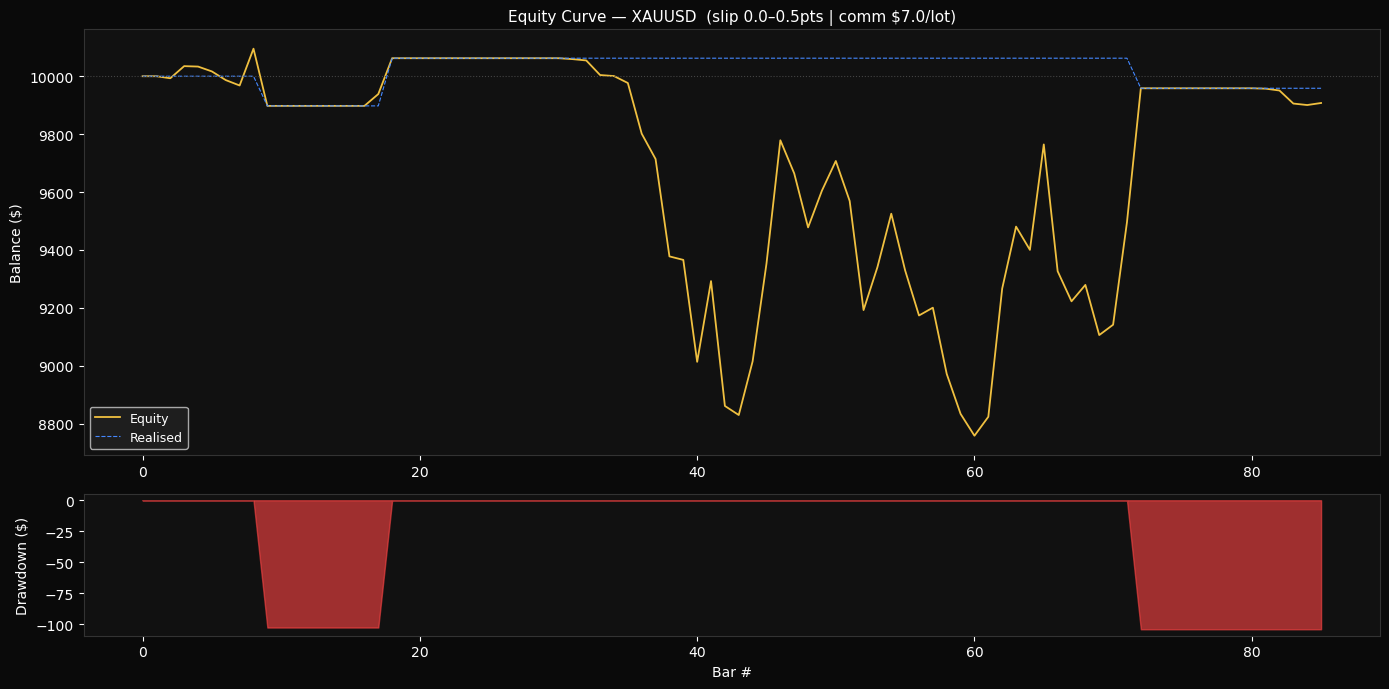

In [9]:

# Load data from MT5
df_raw = load_vantage_data()

# Add Indicators required by scoring engine
df = add_indicators(df_raw)

# Run backtest and generate report (with PnL and other stats)
trades, equity_df = run_backtest(df)
log_df = build_report(trades, equity_df)
